# Tutorial 1: CommonRoad-io
## Reading, Modifying, and Writing Common Scenarios

This tutorial shows how CommonRoad XML-files can be read, modified, visualized, and stored. To start with, a CommonRoad XML-file consists of a **Scenario** and a **PlanningProblemSet**:
* A **Scenario** represents the environment including a **LaneletNetwork** and a set of **DynamicObstacle** and **StaticObstacle**.
    * A **LaneletNetwork** is built from lane segments (**Lanelet**), that can be connected arbitrarily.
* A **PlanningProblemSet** contains one **PlanningProblem** for every ego vehicle in the **Scenario**, consisting of an **initial position** and a **GoalRegion** that has to be reached.

## 0. Preparation
* Before you proceed any further, make sure you have skimmed through [CommonRoad API](https://commonroad-io.readthedocs.io/en/latest/api/) to gain an overall view of the functionalities provided by CommonRoad modules. You may need to refer to it for implementation details throughout this tutorial.

* Additional documentations on **CommonRoad XML format, Cost Functions, Vehicle Models, etc.** can be found at [CommonRoad](https://commonroad.in.tum.de/) on the specific tool pages.

## 1. Read XML file

As documented in [CommonRoadFileReader](https://commonroad-io.readthedocs.io/en/latest/api/common/#module-commonroad.common.file_reader), the **CommonRoadFileReader** reads in a CommonRoad XML file, and its **open()** method returns a **Scenario** and a **PlanningProblemSet** object:

/home/yipyip/Desktop/workspace/miniconda3/envs/cmrio/lib/python3.6/site-packages/commonroad/geometry/shape.py:314: ShapelyDeprecationWarning: Setting custom attributes on geometry objects is deprecated, and will raise an AttributeError in Shapely 2.0
  self.lanelet_id = lanelet_id
/home/yipyip/Desktop/workspace/miniconda3/envs/cmrio/lib/python3.6/site-packages/commonroad/scenario/lanelet.py:1118: ShapelyDeprecationWarning: Iteration over multi-part geometries is deprecated and will be removed in Shapely 2.0. Use the `geoms` property to access the constituent parts of a multi-part geometry.
  for inner_lanelet_buffered_polygon in lanelet_buffered_polygon:


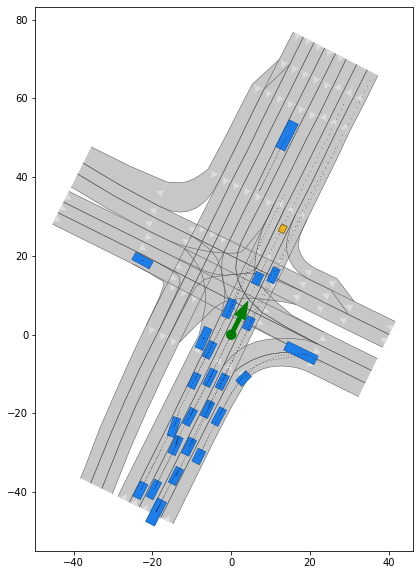

In [1]:
import os
import matplotlib.pyplot as plt
from IPython import display

# import functions to read xml file and visualize commonroad objects
from commonroad.common.file_reader import CommonRoadFileReader
from commonroad.visualization.mp_renderer import MPRenderer

# generate path of the file to be opened
file_path = "USA_Lanker-1_1_T-1.xml"

# read in the scenario and planning problem set
scenario, planning_problem_set = CommonRoadFileReader(file_path).open()

# plot the scenario for 40 time step, here each time step corresponds to 0.1 second
for i in range(0, 1):
    plt.figure(figsize=(25, 10))
    rnd = MPRenderer()
    # plot the scenario at different time step
    scenario.draw(rnd, draw_params={'time_begin': i})
    # plot the planning problem set
    planning_problem_set.draw(rnd)
    rnd.render()


## Filewriter to roadnetwork and obstacle

Exception: Could not produce valid CommonRoad file! Error: Element 'commonRoad', attribute 'commonRoadVersion': [facet 'enumeration'] The value '2020a' is not an element of the set {'2021a'}.

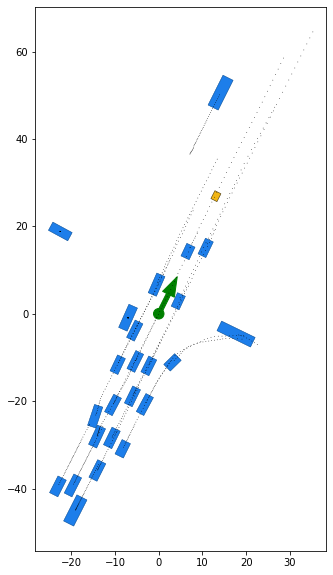

In [2]:
# import necesary classes from different modules
from commonroad.common.file_writer import CommonRoadFileWriter
from commonroad.common.file_writer import OverwriteExistingFile
from commonroad.scenario.scenario import Location
from commonroad.scenario.scenario import Tag
import copy

author = 'Max Mustermann'
affiliation = 'Technical University of Munich, Germany'
source = ''
tags = {Tag.CRITICAL, Tag.INTERSTATE}

# write Roadnetwork
scenario_ob = copy.deepcopy(scenario)
lanelet_list = scenario_ob.lanelet_network.lanelets
for i in range(len(lanelet_list)):
    scenario_ob.lanelet_network.remove_lanelet(lanelet_list[i].lanelet_id)

# plot the scenario for 40 time step, here each time step corresponds to 0.1 second
for i in range(0, 1):
    plt.figure(figsize=(25, 10))
    rnd = MPRenderer()
    # plot the scenario at different time step
    scenario_ob.draw(rnd, draw_params={'time_begin': i})
    # plot the planning problem set
    planning_problem_set.draw(rnd)
    rnd.render()

fw = CommonRoadFileWriter(scenario_ob, planning_problem_set, author, affiliation, source, tags)

filename = "USA_Lanker-1_1_T-1-OBs.xml"
fw.write_to_file(filename, OverwriteExistingFile.ALWAYS, True, 'ObstaclesPlanning')

TypeError: write_scenario_to_file() takes from 1 to 3 positional arguments but 5 were given

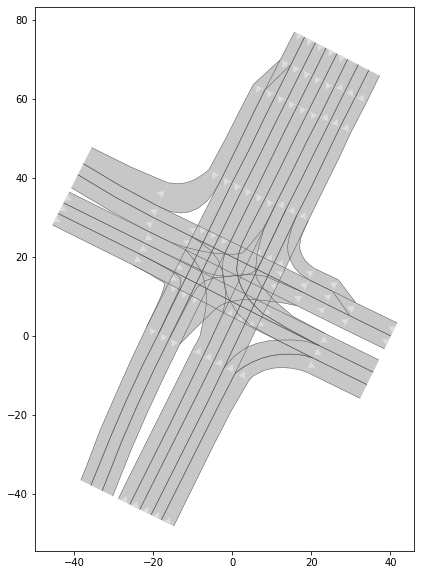

In [3]:
# write Roadnetwork
roadnet = copy.deepcopy(scenario)
obstacle_list = roadnet.obstacles
for i in range(len(obstacle_list)):
    roadnet.remove_obstacle(obstacle_list[i])

# plot the scenario for 40 time step, here each time step corresponds to 0.1 second
for i in range(0, 1):
    plt.figure(figsize=(25, 10))
    rnd = MPRenderer()
    # plot the scenario at different time step
    roadnet.draw(rnd, draw_params={'time_begin': i})
    rnd.render()

fw = CommonRoadFileWriter(roadnet, planning_problem_set, author, affiliation, source, tags)

filename = "ZAM-1_2_T-1-Road.xml"
fw.write_scenario_to_file(filename, OverwriteExistingFile.ALWAYS, True, 'RoadNetwork')

/home/yipyip/Desktop/workspace/miniconda3/envs/cmrrl/lib/python3.6/site-packages/ipykernel_launcher.py:7: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`).
  import sys


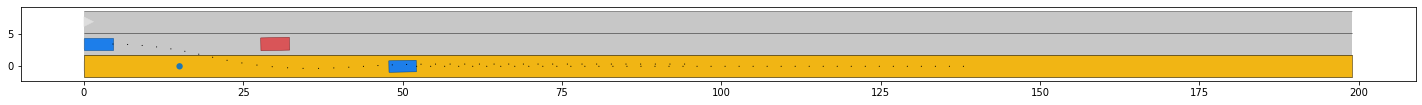

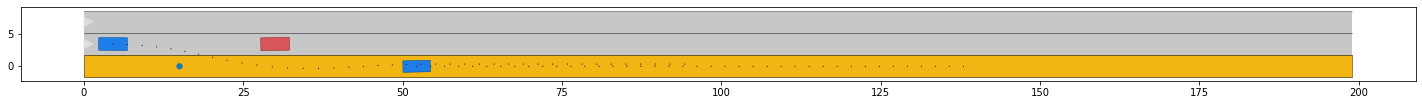

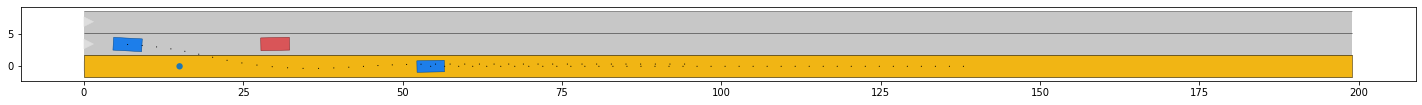

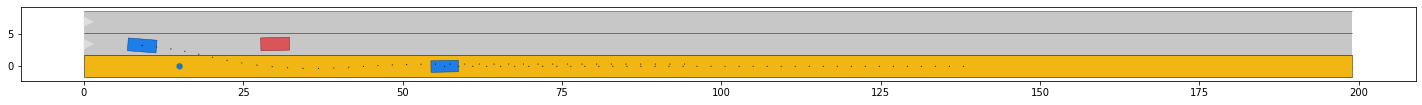

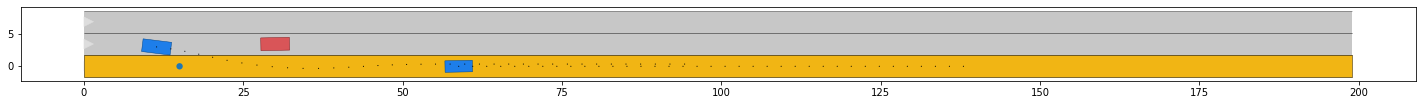

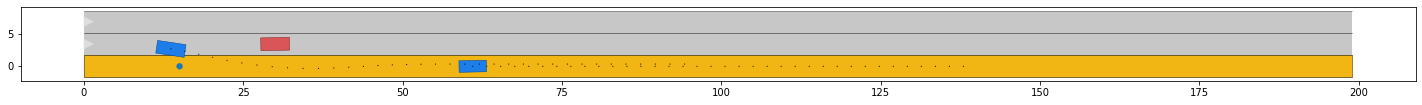

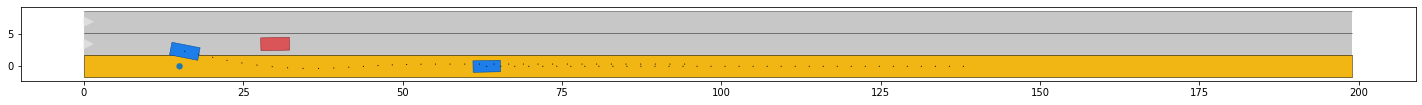

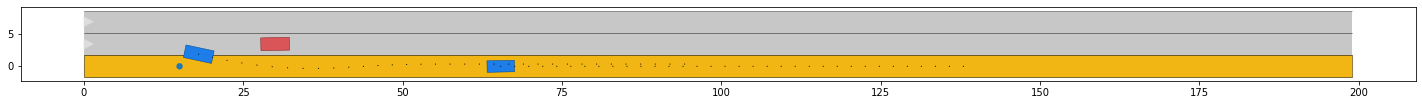

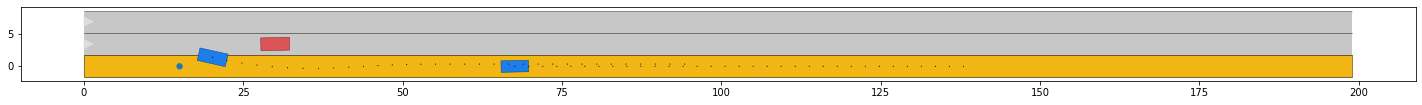

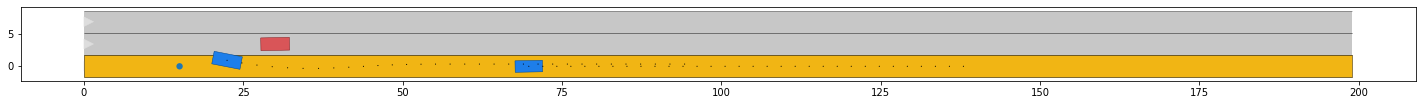

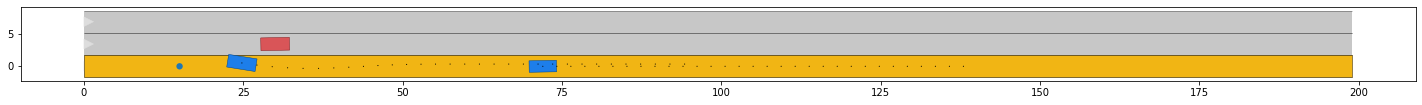

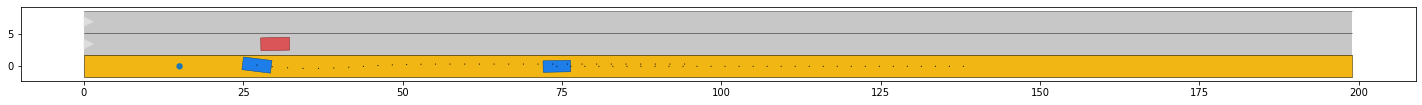

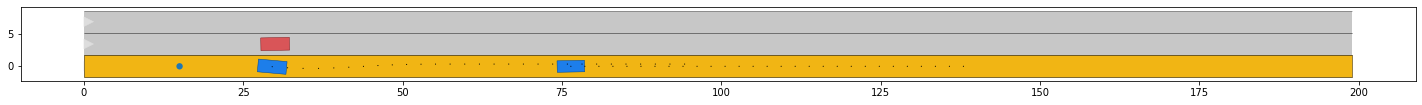

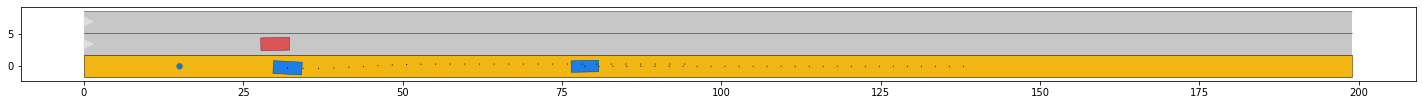

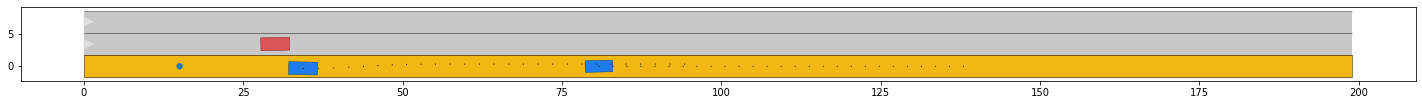

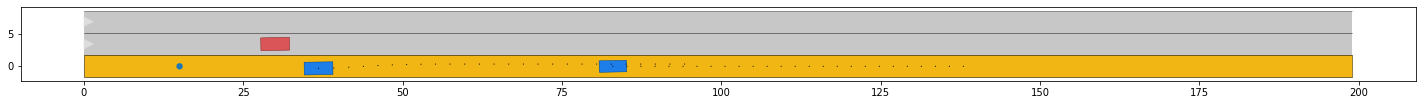

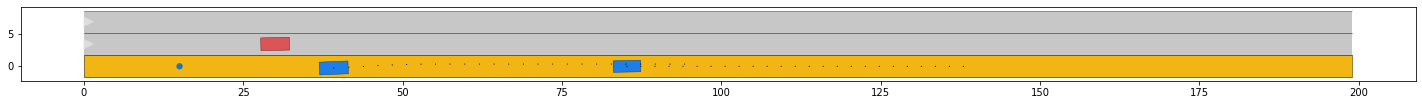

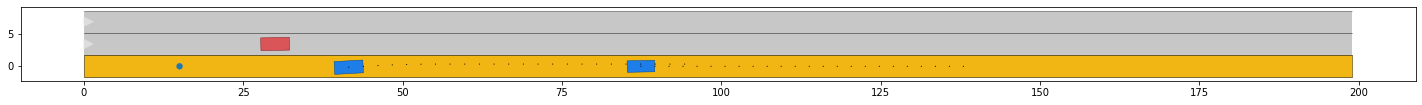

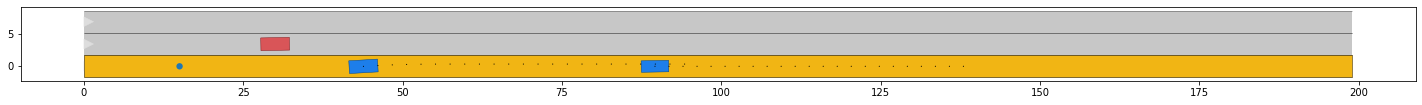

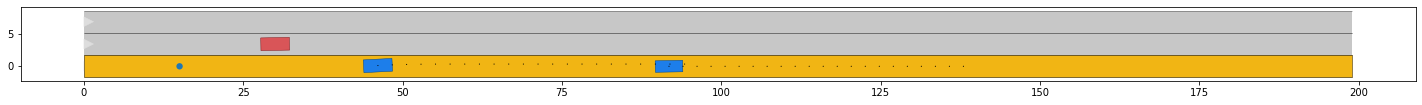

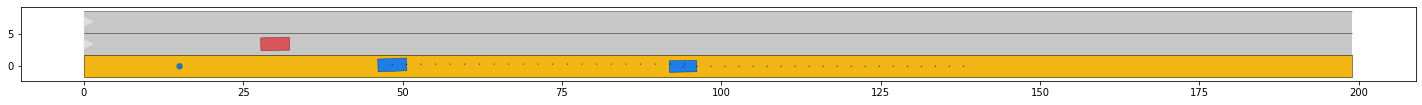

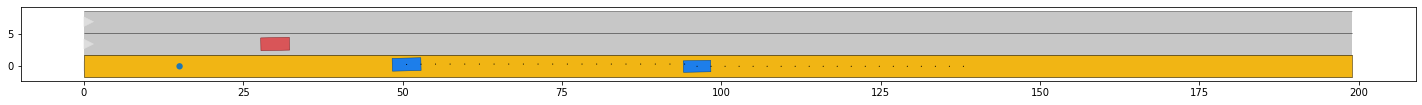

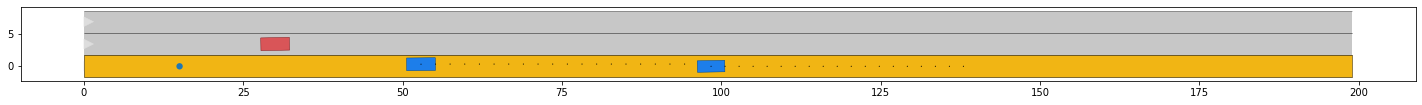

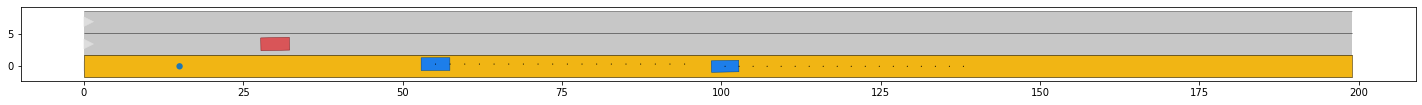

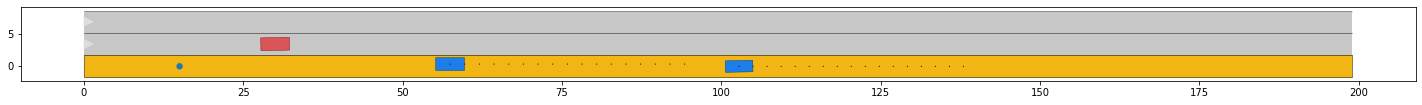

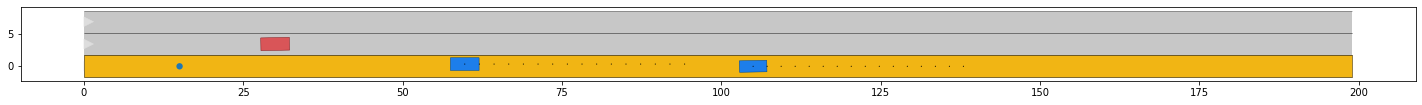

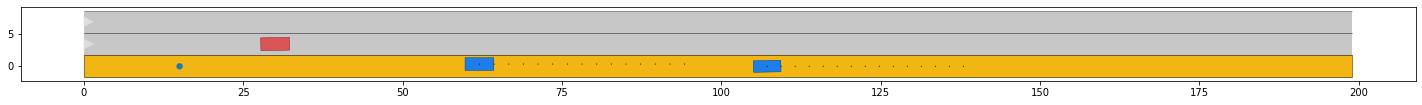

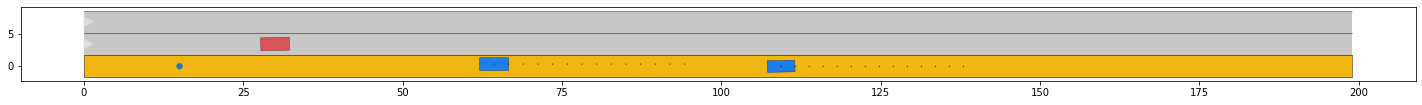

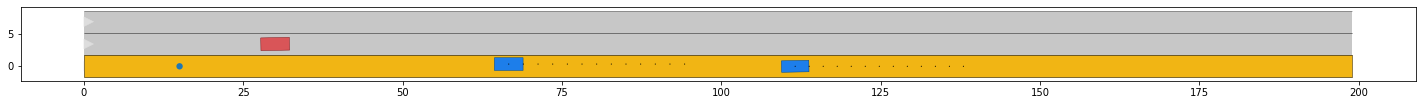

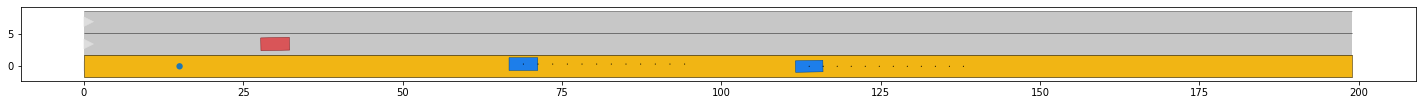

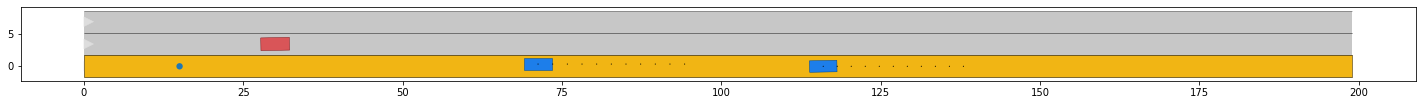

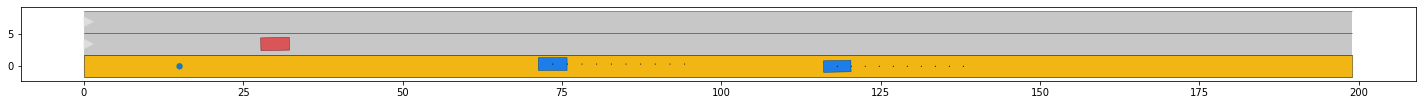

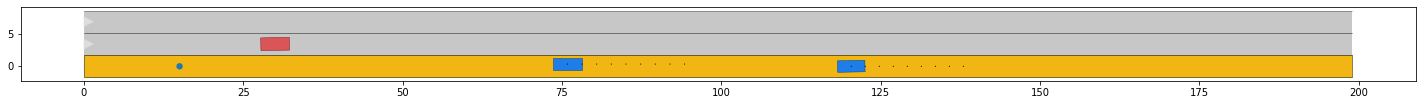

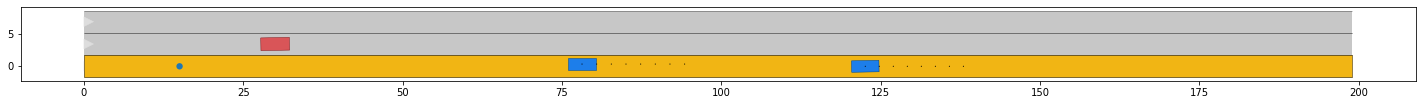

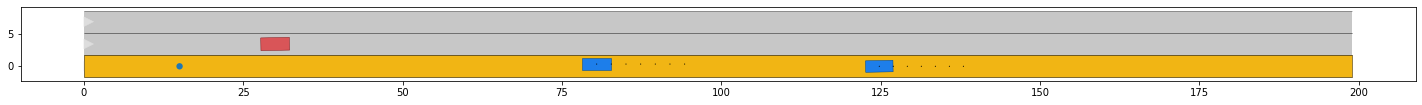

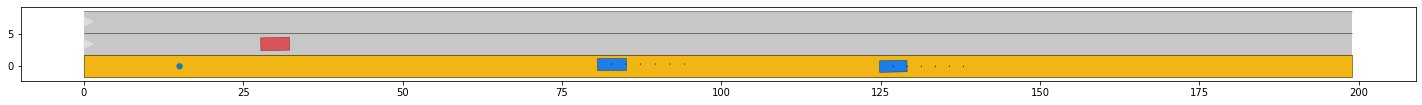

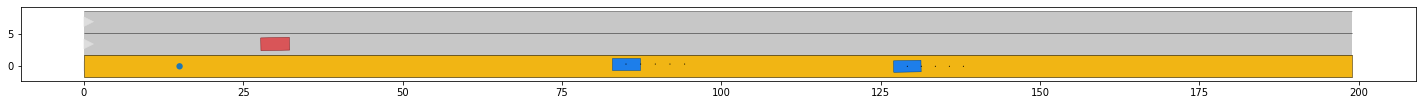

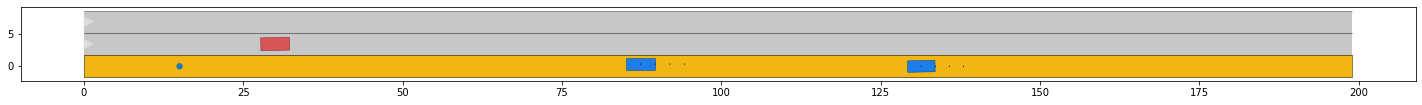

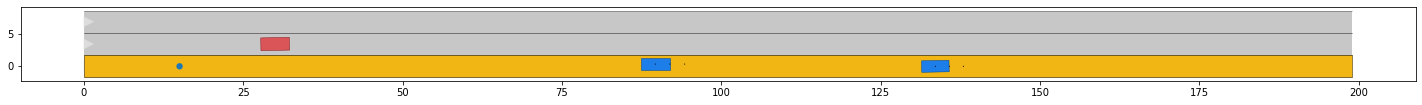

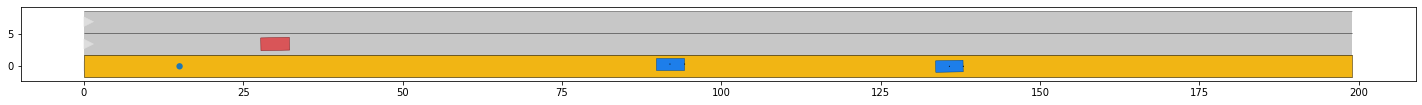

In [7]:
file_path = "ZAM_Tutorial-1_2_T-1.xml"

scenario, planning_problem_set = CommonRoadFileReader(file_path).open()

# plot the scenario for each time step
for i in range(0, 40):
    plt.figure(figsize=(25, 10))
    rnd = MPRenderer()
    scenario.draw(rnd, draw_params={'time_begin': i})
    planning_problem_set.draw(rnd)
    rnd.render()